In [19]:
#!pip install pandas matplotlib statsmodels scikit-learn

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Load the dataset
df = pd.read_csv('dataset.csv')

df.head()

,Date,Date #,total # of customers,Total # of new customers,Total Sales,total COA\nCost of Aqusistion,# of active customers (postpd),# of inactive customers (postpd),Total Data Sales,Total Voice Sales,...,Unnamed: 16371,Unnamed: 16372,Unnamed: 16373,Unnamed: 16374,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Total Sales in SS.1
0,Jan-21,1.0,"126,162,949","262,616","₦ 2,723,737,272.00","₦ 38,182,727.00","13,654,425","817,272","₦ 1,929,281,276.00","₦ 616,252,249.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Feb-21,2.0,"126,301,182","212,919","₦ 3,172,727,172.00","₦ 36,172,772.00","13,766,564","716,262","₦ 2,087,272,712.00","₦ 983,823,911.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mar-21,3.0,"126,718,282","191,828","₦ 3,717,272,662.00","₦ 41,392,872.00","13,817,266","812,272","₦ 2,312,627,209.00","₦ 1,018,282,024.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Apr-21,4.0,"131,001,929","213,301","₦ 4,128,182,882.00","₦ 37,172,626.00","13,988,782","791,887","₦ 2,282,817,298.00","₦ 1,274,815,836.33",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,May-21,5.0,"131,279,596","234,123","₦ 4,624,950,577.00","₦ 40,192,828.00","14,070,203","910,282","₦ 3,417,272,711.00","₦ 951,830,723.83",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Columns: 16381 entries, Date to Total Sales in SS.1
dtypes: float64(16308), object(73)
memory usage: 8.2+ MB


In [23]:
features = ['Date', 'Total Sales']
df = df[features]
df.head(60)

,Date,Total Sales
0,Jan-21,"₦ 2,723,737,272.00"
1,Feb-21,"₦ 3,172,727,172.00"
2,Mar-21,"₦ 3,717,272,662.00"
3,Apr-21,"₦ 4,128,182,882.00"
4,May-21,"₦ 4,624,950,577.00"
5,Jun-21,"₦ 5,100,738,809.00"
6,Jul-21,"₦ 5,576,527,041.00"
7,Aug-21,"₦ 6,052,315,273.00"
8,Sept-21,"₦ 6,528,103,505.00"
9,Oct-21,"₦ 7,003,891,737.00"


In [24]:
missing_count = df.isnull().sum()
missing_count

Date           6
Total Sales    6
dtype: int64

In [25]:
df = df.dropna()

In [26]:
missing_count = df.isnull().sum()
missing_count

Date           0
Total Sales    0
dtype: int64

In [27]:
# Data preprocessing
# Convert date to proper datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Clean and convert Total Sales to numeric
df['Total Sales'] = df['Total Sales'].str.replace('₦', '').str.replace(',', '').str.replace(' ', '').astype(float)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print("Dataset Overview:")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of months: {len(df)}")
print(f"Total Sales range: ₦{df['Total Sales'].min():,.2f} to ₦{df['Total Sales'].max():,.2f}")


Dataset Overview:
Date range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 60
Total Sales range: ₦2,723,737,272.00 to ₦30,793,303,337.00


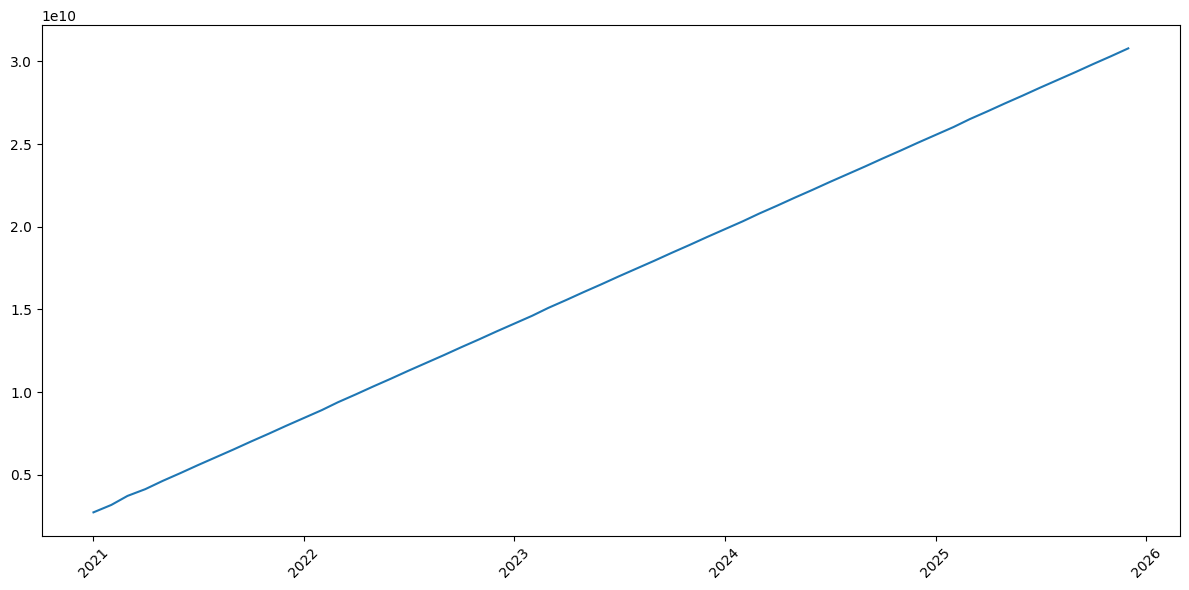

In [28]:
# Absolute simplest version
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Total Sales'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

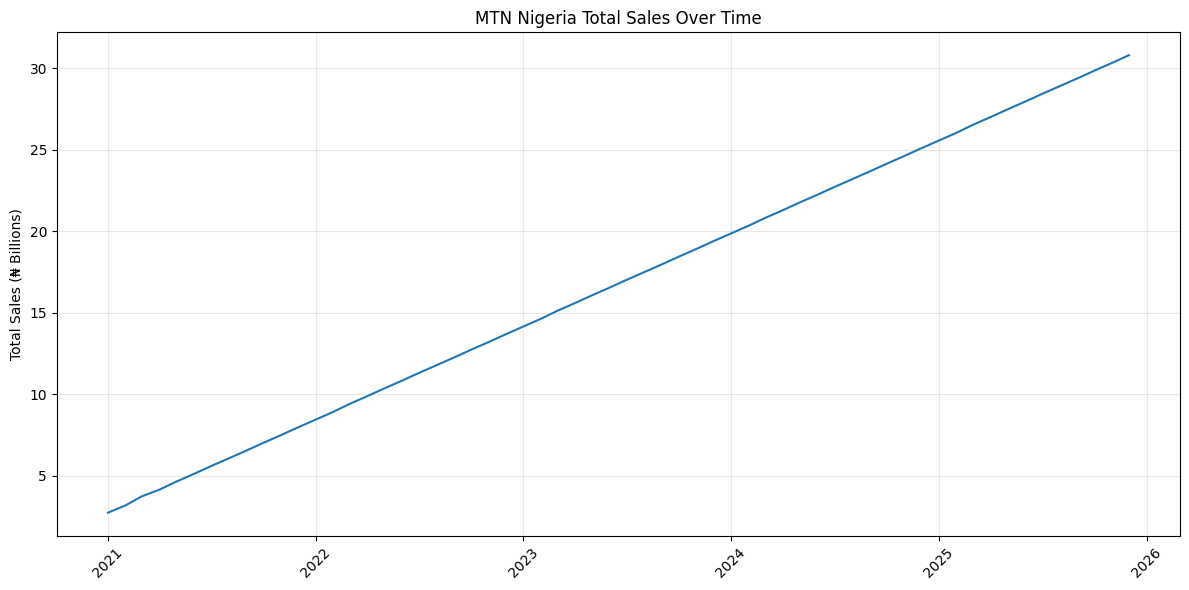

In [29]:
plt.figure(figsize=(12, 6))

# Plot in billions for better readability
plt.plot(df['Date'], df['Total Sales'] / 1e9)  # Divide by 1 billion
plt.title('MTN Nigeria Total Sales Over Time')
plt.ylabel('Total Sales (₦ Billions)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

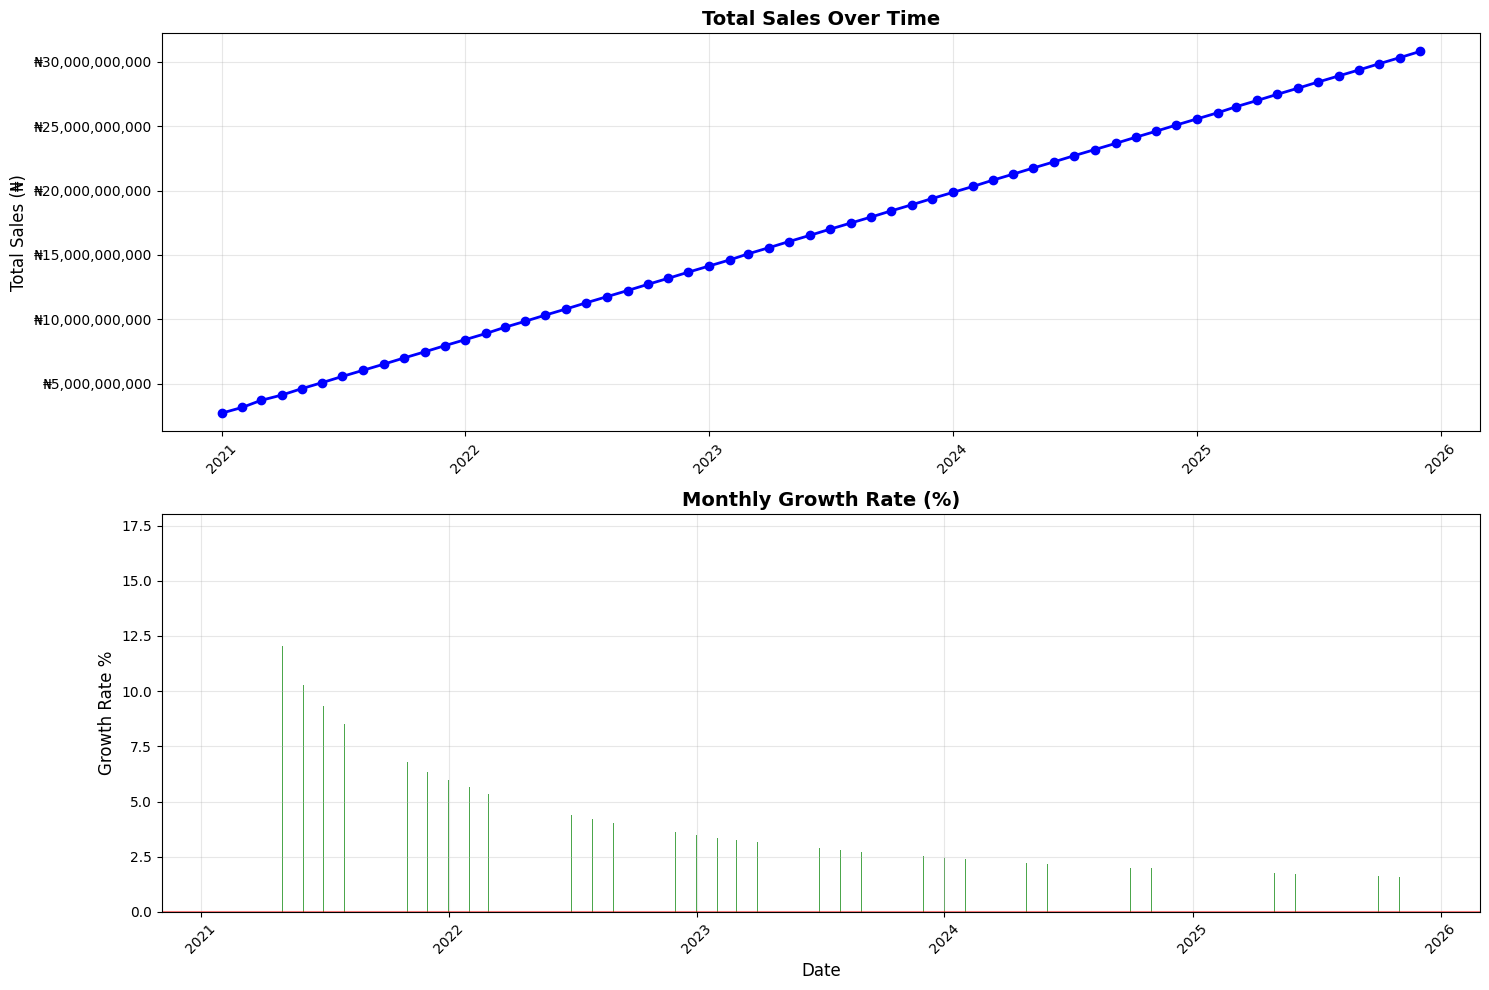

SALES SUMMARY:
Date Range: 2021-01-01 00:00:00 to 2025-12-01 00:00:00
Total Months: 60
Highest Sales: ₦30,793,303,337.00
Lowest Sales: ₦2,723,737,272.00
Average Monthly Sales: ₦16,757,550,493.00
Total Growth: 1030.6%


In [30]:
# Version with growth analysis
plt.figure(figsize=(15, 8))

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Sales trend
ax1.plot(df['Date'], df['Total Sales'], 'o-', linewidth=2, color='blue')
ax1.set_title('Total Sales Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel('Total Sales (₦)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}'))
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Monthly growth rate
monthly_growth = df['Total Sales'].pct_change() * 100
ax2.bar(df['Date'], monthly_growth, color='green', alpha=0.7)
ax2.set_title('Monthly Growth Rate (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Growth Rate %', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add zero line for growth chart
ax2.axhline(y=0, color='red', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("SALES SUMMARY:")
print(f"Date Range: {df['Date'].iloc[0]} to {df['Date'].iloc[-1]}")
print(f"Total Months: {len(df)}")
print(f"Highest Sales: ₦{df['Total Sales'].max():,.2f}")
print(f"Lowest Sales: ₦{df['Total Sales'].min():,.2f}")
print(f"Average Monthly Sales: ₦{df['Total Sales'].mean():,.2f}")
print(f"Total Growth: {((df['Total Sales'].iloc[-1] / df['Total Sales'].iloc[0]) - 1) * 100:.1f}%")

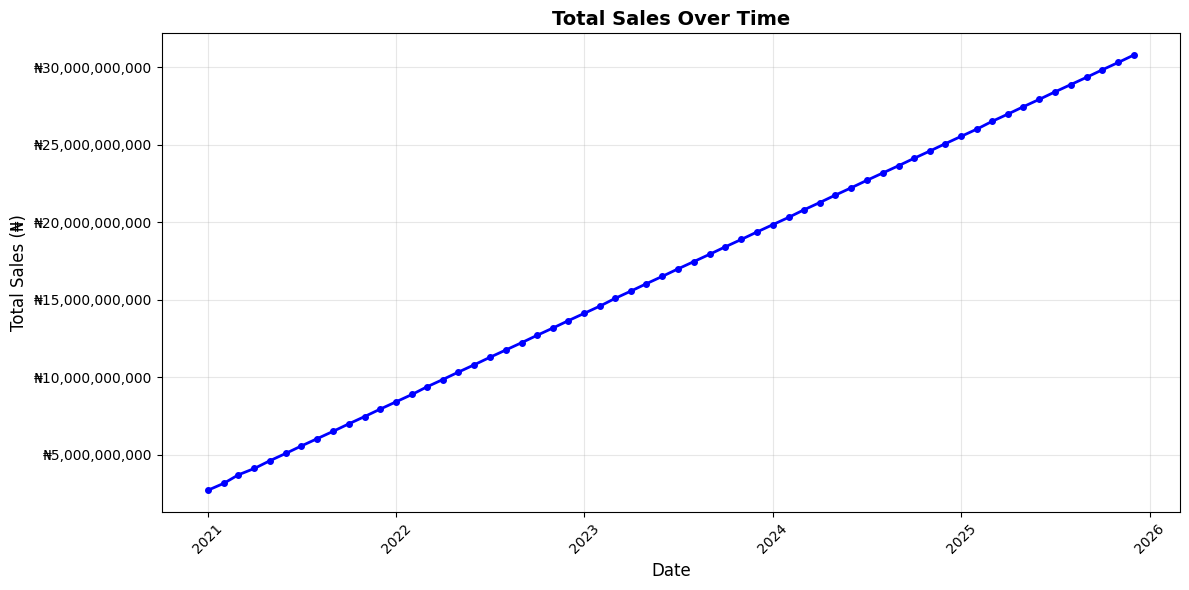

In [31]:
# Create the line chart
plt.figure(figsize=(12, 6))

# Plot Date vs Total Sales
plt.plot(df['Date'], df['Total Sales'], 
         marker='o', linewidth=2, markersize=4, color='blue')

# Formatting
plt.title('Total Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (₦)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}'))

# Add grid
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

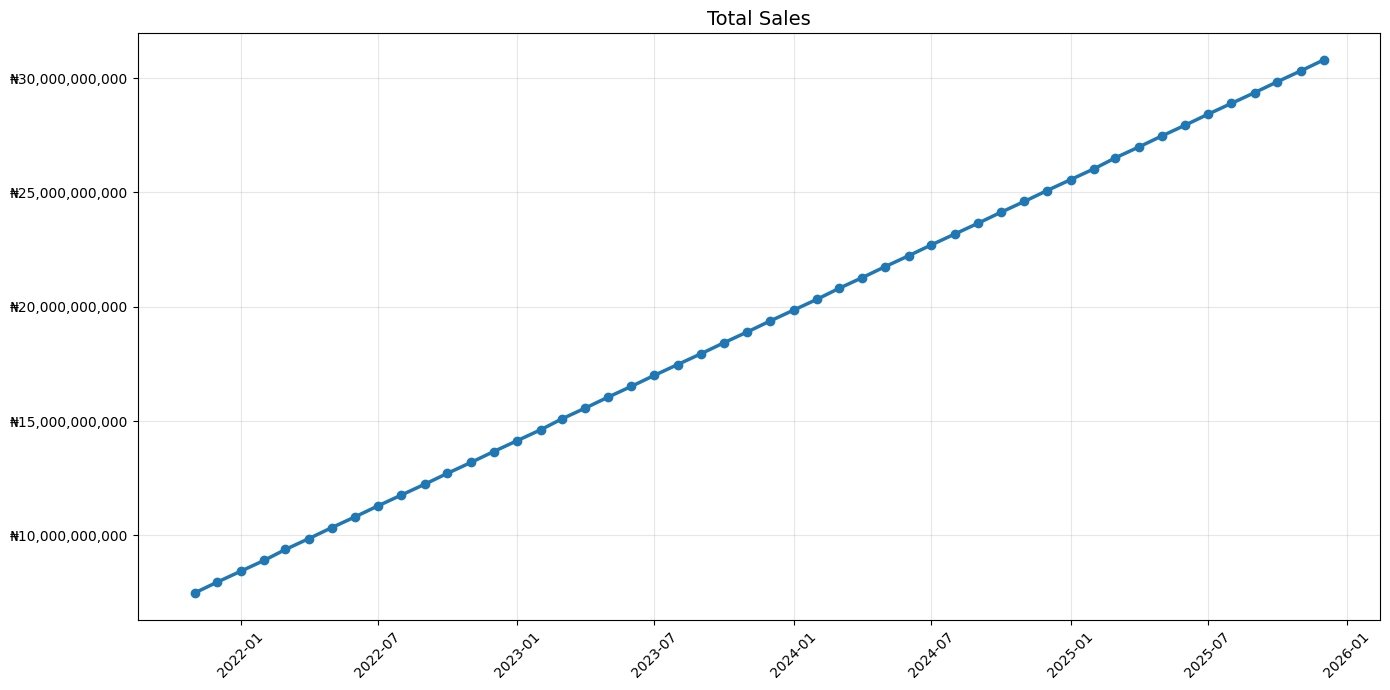

In [32]:
# Zoom to last 12 months only
plt.figure(figsize=(14, 7))

# Get last 12 months
recent_data = df.tail(50)

plt.plot(recent_data['Date'], recent_data['Total Sales'], marker='o', linewidth=2.5)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}'))
plt.title('Total Sales', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

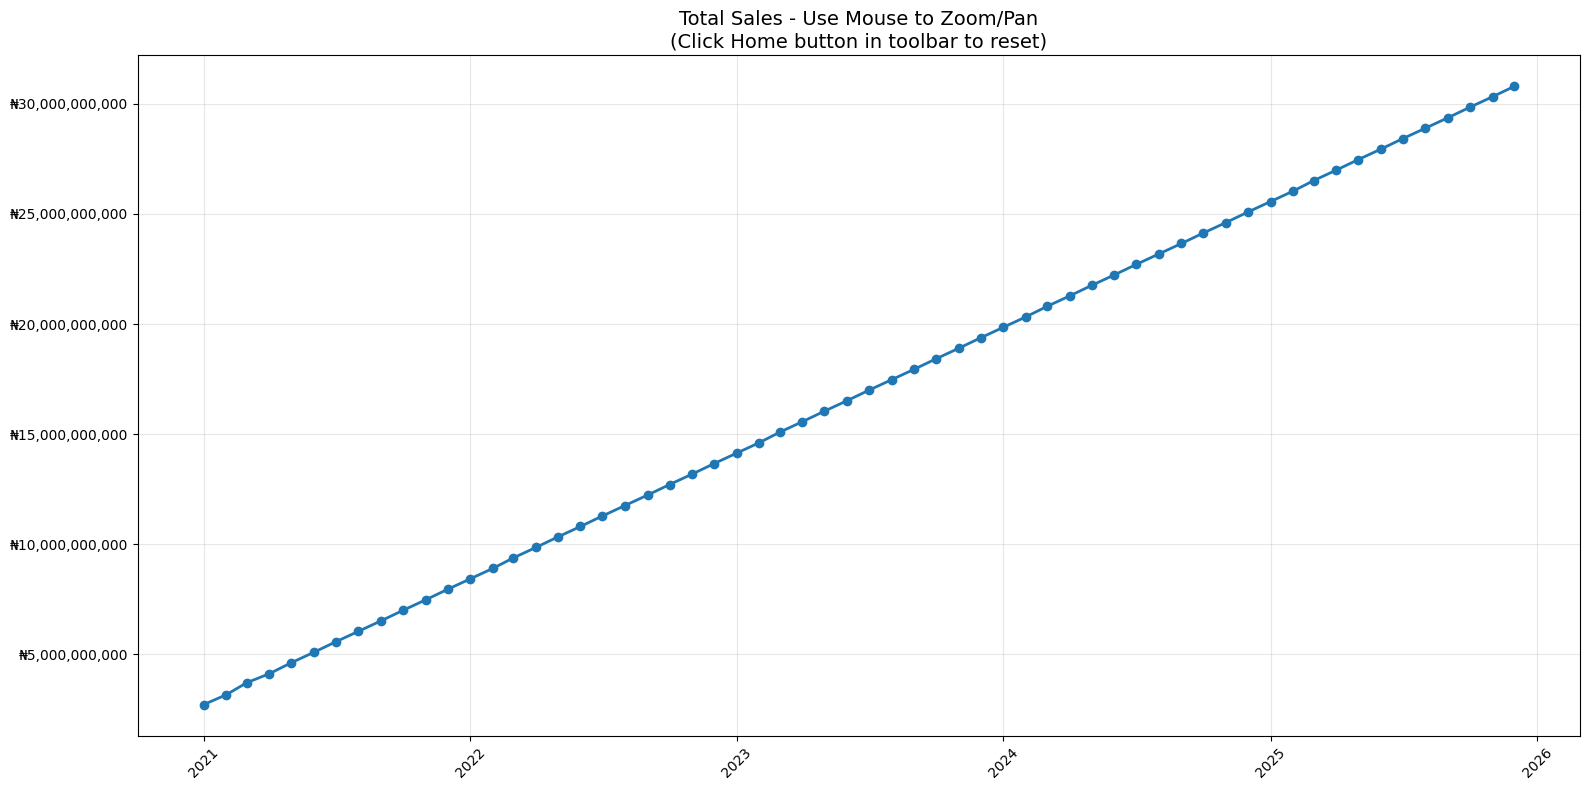

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.plot(df['Date'], df['Total Sales'], marker='o', linewidth=2)

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}'))
plt.title('Total Sales - Use Mouse to Zoom/Pan\n(Click Home button in toolbar to reset)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# This enables the interactive toolbar with zoom/pan features
plt.show()

In [34]:
!pip install nbformat>=4.2.0
!pip install jupyterlab-plotly 
import plotly.express as px
import plotly.graph_objects as go


# Convert sales to billions for cleaner hover display
df['Total_Sales_Billions'] = df['Total Sales'] / 1e9

# Create interactive plot
fig = px.line(df, 
              x='Date', 
              y='Total_Sales_Billions',
              title='Total Sales Over Time (Interactive)',
              labels={'Total_Sales_Billions': 'Total Sales (₦ Billions)', 'Date': 'Date'})

# Customize hover template
fig.update_traces(
    hovertemplate="<br>".join([
        "Date: %{x}",
        "Sales: ₦%{y:.3f}B",
        "<extra></extra>"
    ]),
    line=dict(width=3),
    marker=dict(size=6)
)

# Show the plot
fig.show()

ERROR: Could not find a version that satisfies the requirement jupyterlab-plotly (from versions: none)
ERROR: No matching distribution found for jupyterlab-plotly


In [44]:
# Absolute simplest Plotly version
import plotly.express as px

fig = px.line(df, x='Date', y='Total Sales', title='Total Sales')
fig.show()

In [45]:
# If you have other columns you want to show in hover
fig = px.line(df, 
              x='Date', 
              y='Total Sales',
              title='Sales with Multiple Metrics in Tooltip')

# If you have additional columns, include them in hover_data
fig.update_traces(
    hovertemplate="<br>".join([
        "<b>%{x}</b>",
        "Total Sales: <b>₦%{y:,.0f}</b>",
        "Month Number: %{customdata[0]}",
        "<extra></extra>"
    ]),
    customdata=df[['Month_Num']]  # Add month numbers to hover
)

fig.show()

In [48]:
import plotly.express as px

# Calculate monthly growth percentage
df['Monthly_Growth_Pct'] = df['Total Sales'].pct_change() * 100

# Create the plot
fig = px.line(df, 
              x='Date', 
              y='Total Sales',
              title='Sales with Multiple Metrics in Tooltip')

# Enhanced hover template with monthly growth
fig.update_traces(
    hovertemplate="<br>".join([
        "<b>%{x}</b>",
        "Total Sales: <b>₦%{y:,.0f}</b>",
        "Month Number: %{customdata[0]}",
        "Monthly Growth: <b>%{customdata[1]:.2f}%</b>",
        "<extra></extra>"
    ]),
    customdata=df[['Month_Num', 'Monthly_Growth_Pct']],  # Add both month numbers and growth
    line=dict(width=3, color='#1f77b4'),
    marker=dict(size=6, color='#ff7f0e')
)

# Add some styling
fig.update_layout(
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    ),
    xaxis=dict(tickangle=45),
    yaxis=dict(tickformat=",."),  # Format with commas
    template='plotly_white'
)

fig.show()

In [50]:
import plotly.express as px

# Calculate growth
df['Monthly_Growth_Pct'] = df['Total Sales'].pct_change() * 100

fig = px.line(df, x='Date', y='Total Sales')

fig.update_traces(
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Sales: ₦%{y:,.0f}<br>"
        "Month: %{customdata[0]}<br>"
        "Growth: %{customdata[1]:.1f}%"
        "<extra></extra>"
    ),
    customdata=df[['Month_Num', 'Monthly_Growth_Pct']]
)

fig.show()

In [37]:
# Create features for forecasting
df['Month_Num'] = range(1, len(df) + 1)
df['Quarter'] = (df['Month_Num'] - 1) // 3 + 1

In [38]:
df.head()

,Date,Total Sales,Total_Sales_Billions,Month_Num,Quarter
0,2021-01-01,2.723737e+09,2.723737,1,1
1,2021-02-01,3.172727e+09,3.172727,2,1
2,2021-03-01,3.717273e+09,3.717273,3,1
3,2021-04-01,4.128183e+09,4.128183,4,2
4,2021-05-01,4.624951e+09,4.624951,5,2


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  60 non-null     datetime64[ns]
 1   Total Sales           60 non-null     float64       
 2   Total_Sales_Billions  60 non-null     float64       
 3   Month_Num             60 non-null     int64         
 4   Quarter               60 non-null     int64         
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 2.5 KB


In [40]:
# Prepare data for modeling
X = df[['Month_Num']]
y = df['Total Sales']

# Use last 12 months (1 year) for testing, rest for training
test_months = 12
train_size = len(df) - test_months

print(f"Data split: {train_size} months training, {test_months} months testing")

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

Data split: 48 months training, 12 months testing


In [41]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Forecast future Sales
future_months = 12
last_month = df['Month_Num'].max()  # Should be 60
future_X = pd.DataFrame({
    'Month_Num': range(last_month + 1, last_month + future_months + 1)
})
future_predictions = lr_model.predict(future_X)

In [42]:
print("FUTURE FORECAST (Next 12 Months):")
for i, (month, sales) in enumerate(zip(future_X['Month_Num'], future_predictions), 1):
    print(f"Month {i}: ₦{sales:,.2f} (Month number {month})")

FUTURE FORECAST (Next 12 Months):
Month 1: ₦31,269,091,569.00 (Month number 61)
Month 2: ₦31,744,879,801.00 (Month number 62)
Month 3: ₦32,220,668,033.00 (Month number 63)
Month 4: ₦32,696,456,265.00 (Month number 64)
Month 5: ₦33,172,244,497.00 (Month number 65)
Month 6: ₦33,648,032,729.00 (Month number 66)
Month 7: ₦34,123,820,961.00 (Month number 67)
Month 8: ₦34,599,609,193.00 (Month number 68)
Month 9: ₦35,075,397,425.00 (Month number 69)
Month 10: ₦35,551,185,657.00 (Month number 70)
Month 11: ₦36,026,973,889.00 (Month number 71)
Month 12: ₦36,502,762,121.00 (Month number 72)


In [43]:
# evaluate the model on TEST data
test_predictions = lr_model.predict(X_test)

test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("MODEL PERFORMANCE ON TEST DATA (Last 12 Months):")
print(f"MAE:  ₦{test_mae:,.2f}")
print(f"RMSE: ₦{test_rmse:,.2f}")
print(f"R² Score: {test_r2:.4f}")
print(f"Accuracy: {test_r2*100:.1f}% of variance explained")

NameError: name 'r2_score' is not defined

In [ ]:
# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Month_Num': df['Month_Num'],
    'Actual_Sales': df['Total Sales'],
    'Type': ['Historical'] * len(df)
})

# Add test predictions to results
test_results = pd.DataFrame({
    'Month_Num': X_test['Month_Num'],
    'Actual_Sales': y_test,
    'Predicted_Sales': test_predictions,
    'Type': ['Test'] * len(X_test)
})

# Add future forecasts
future_results = pd.DataFrame({
    'Month_Num': future_X['Month_Num'],
    'Predicted_Sales': future_predictions,
    'Type': ['Future'] * len(future_X)
})

# Combine all results
all_results = pd.concat([
    results_df[results_df['Month_Num'].isin(X_train['Month_Num'])],
    test_results,
    future_results
], ignore_index=True)

print(f"\nDATA SPLIT SUMMARY:")
print(f"Training months: {len(X_train)} (Months 1-{X_train['Month_Num'].max()})")
print(f"Testing months:  {len(X_test)} (Months {X_test['Month_Num'].min()}-{X_test['Month_Num'].max()})")
print(f"Forecast months: {len(future_X)} (Months {future_X['Month_Num'].min()}-{future_X['Month_Num'].max()})")


DATA SPLIT SUMMARY:
Training months: 48 (Months 1-48)
Testing months:  12 (Months 49-60)
Forecast months: 12 (Months 61-72)


In [ ]:
all_results

,Month_Num,Actual_Sales,Type,Predicted_Sales
0,1,2.723737e+09,Historical,NaN
1,2,3.172727e+09,Historical,NaN
2,3,3.717273e+09,Historical,NaN
3,4,4.128183e+09,Historical,NaN
4,5,4.624951e+09,Historical,NaN
...,...,...,...,...
67,68,NaN,Future,3.459961e+10
68,69,NaN,Future,3.507540e+10
69,70,NaN,Future,3.555119e+10
70,71,NaN,Future,3.602697e+10


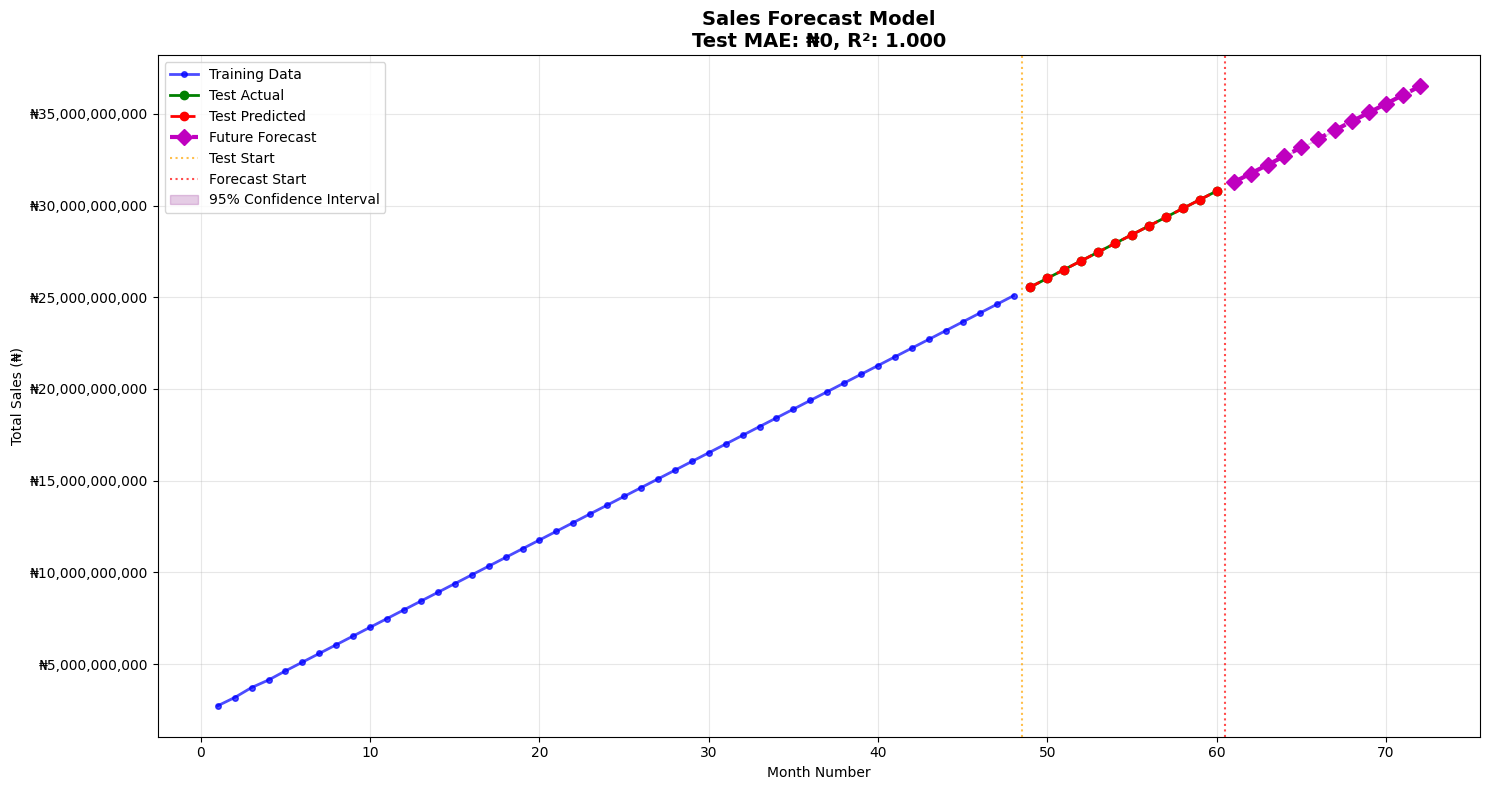

In [ ]:
import matplotlib.pyplot as plt

def create_comprehensive_plot(df, all_results, test_mae, test_r2):
    plt.figure(figsize=(15, 8))
    
    # Plot historical training data
    historical_data = all_results[all_results['Type'] == 'Historical']
    plt.plot(historical_data['Month_Num'], historical_data['Actual_Sales'], 
             'bo-', label='Training Data', linewidth=2, markersize=4, alpha=0.7)
    
    # Plot test actual vs predicted
    test_data = all_results[all_results['Type'] == 'Test']
    plt.plot(test_data['Month_Num'], test_data['Actual_Sales'], 
             'go-', label='Test Actual', linewidth=2, markersize=6)
    plt.plot(test_data['Month_Num'], test_data['Predicted_Sales'], 
             'ro--', label='Test Predicted', linewidth=2, markersize=6)
    
    # Plot future forecast
    future_data = all_results[all_results['Type'] == 'Future']
    plt.plot(future_data['Month_Num'], future_data['Predicted_Sales'], 
             'mD--', label='Future Forecast', linewidth=3, markersize=8)
    
    # Add vertical lines to separate regions
    last_train_month = X_train['Month_Num'].max()
    last_test_month = X_test['Month_Num'].max()
    
    plt.axvline(x=last_train_month + 0.5, color='orange', linestyle=':', 
                alpha=0.7, label='Test Start')
    plt.axvline(x=last_test_month + 0.5, color='red', linestyle=':', 
                alpha=0.7, label='Forecast Start')
    
    # Add confidence interval for future forecast (simple version)
    future_std = np.std(test_data['Actual_Sales'] - test_data['Predicted_Sales'])
    plt.fill_between(future_data['Month_Num'], 
                    future_data['Predicted_Sales'] - 1.96 * future_std,
                    future_data['Predicted_Sales'] + 1.96 * future_std,
                    alpha=0.2, color='purple', label='95% Confidence Interval')
    
    plt.title(f'Sales Forecast Model\nTest MAE: ₦{test_mae:,.0f}, R²: {test_r2:.3f}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Month Number')
    plt.ylabel('Total Sales (₦)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Format y-axis as currency
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₦{x:,.0f}'))
    
    plt.tight_layout()
    plt.show()

# Create the plot
create_comprehensive_plot(df, all_results, test_mae, test_r2)

In [ ]:
def generate_forecast_report(future_results, test_mae, test_r2):
    print("=" * 60)
    print("FORECAST REPORT")
    print("=" * 60)
    
    # Calculate growth metrics
    current_sales = df['Total Sales'].iloc[-1]  # Last actual sales
    first_forecast = future_results['Predicted_Sales'].iloc[0]
    growth_1month = ((first_forecast - current_sales) / current_sales) * 100
    
    last_forecast = future_results['Predicted_Sales'].iloc[-1]
    growth_6month = ((last_forecast - current_sales) / current_sales) * 100
    
    print(f"Current Sales (Month {df['Month_Num'].max()}): ₦{current_sales:,.2f}")
    print(f"Model Reliability (R² on test data): {test_r2:.1%}")
    print(f"Typical Prediction Error: ₦{test_mae:,.2f}")
    
    print(f"\n6-MONTH FORECAST DETAILS:")
    print("-" * 40)
    for i, row in future_results.iterrows():
        month_growth = ((row['Predicted_Sales'] - current_sales) / current_sales) * 100
        print(f"Month {row['Month_Num']}: ₦{row['Predicted_Sales']:,.2f} ({month_growth:+.1f}%)")
    
    print(f"\nSUMMARY:")
    print(f"1-month growth forecast: {growth_1month:+.1f}%")
    print(f"6-month growth forecast: {growth_6month:+.1f}%")
    print(f"Average monthly growth: {(growth_6month/6):+.1f}%")

# Generate report
generate_forecast_report(future_results, test_mae, test_r2)

FORECAST REPORT
Current Sales (Month 60): ₦30,793,303,337.00
Model Reliability (R² on test data): 100.0%
Typical Prediction Error: ₦0.00

6-MONTH FORECAST DETAILS:
----------------------------------------
Month 61: ₦31,269,091,569.00 (+1.5%)
Month 62: ₦31,744,879,801.00 (+3.1%)
Month 63: ₦32,220,668,033.00 (+4.6%)
Month 64: ₦32,696,456,265.00 (+6.2%)
Month 65: ₦33,172,244,497.00 (+7.7%)
Month 66: ₦33,648,032,729.00 (+9.3%)
Month 67: ₦34,123,820,961.00 (+10.8%)
Month 68: ₦34,599,609,193.00 (+12.4%)
Month 69: ₦35,075,397,425.00 (+13.9%)
Month 70: ₦35,551,185,657.00 (+15.5%)
Month 71: ₦36,026,973,889.00 (+17.0%)
Month 72: ₦36,502,762,121.00 (+18.5%)

SUMMARY:
1-month growth forecast: +1.5%
6-month growth forecast: +18.5%
Average monthly growth: +3.1%


In [ ]:
def interpret_model(lr_model, df):
    """Explain what the model learned"""
    coefficients = lr_model.coef_[0]
    intercept = lr_model.intercept_
    
    print("\n" + "=" * 50)
    print("MODEL INTERPRETATION")
    print("=" * 50)
    print(f"Sales = {intercept:,.0f} + {coefficients:,.0f} × Month_Num")
    print(f"\nThis means:")
    print(f"• Starting point: ₦{intercept:,.0f} (theoretical sales at month 0)")
    print(f"• Monthly growth: ₦{coefficients:,.0f} per month")
    print(f"• Annual growth: ₦{coefficients * 12:,.0f} per year")
    
    # Calculate actual vs predicted growth
    actual_monthly_growth = df['Total Sales'].pct_change().mean() * 100
    print(f"• Actual historical monthly growth: {actual_monthly_growth:.1f}%")
    print(f"• Model predicted monthly growth: {(coefficients/df['Total Sales'].mean())*100:.1f}%")

# Interpret the model
interpret_model(lr_model, df)


MODEL INTERPRETATION
Sales = 2,246,009,417 + 475,788,232 × Month_Num

This means:
• Starting point: ₦2,246,009,417 (theoretical sales at month 0)
• Monthly growth: ₦475,788,232 per month
• Annual growth: ₦5,709,458,784 per year
• Actual historical monthly growth: 4.3%
• Model predicted monthly growth: 2.8%


In [ ]:
# Save forecast to CSV
forecast_export = future_results.copy()
forecast_export['Date'] = [f'Month {int(month)}' for month in forecast_export['Month_Num']]
forecast_export = forecast_export[['Date', 'Month_Num', 'Predicted_Sales']]
forecast_export.columns = ['Period', 'Month_Number', 'Forecasted_Sales']

# Format currency
forecast_export['Forecasted_Sales'] = forecast_export['Forecasted_Sales'].apply(
    lambda x: f'₦{x:,.2f}'
)

print("\nFORECAST FOR EXPORT:")
print(forecast_export.to_string(index=False))

# Save to file
forecast_export.to_csv('sales_forecast_next_6months.csv', index=False)
print("\nForecast saved to 'sales_forecast_next_6months.csv'")


FORECAST FOR EXPORT:
  Period  Month_Number   Forecasted_Sales
Month 61            61 ₦31,269,091,569.00
Month 62            62 ₦31,744,879,801.00
Month 63            63 ₦32,220,668,033.00
Month 64            64 ₦32,696,456,265.00
Month 65            65 ₦33,172,244,497.00
Month 66            66 ₦33,648,032,729.00
Month 67            67 ₦34,123,820,961.00
Month 68            68 ₦34,599,609,193.00
Month 69            69 ₦35,075,397,425.00
Month 70            70 ₦35,551,185,657.00
Month 71            71 ₦36,026,973,889.00
Month 72            72 ₦36,502,762,121.00

Forecast saved to 'sales_forecast_next_6months.csv'
